# Where the Flip Deals Actually Are

Real deals cluster where **3 forces overlap:**

1. The property is **cheaper per sqft** than similar homes
2. There's **distress** — foreclosure, price drops
3. The market is **ignoring** it — been sitting, nobody wants it

But the house itself is still **livable** — good size, enough rooms.

This notebook scores every property on those factors and shows you exactly where the opportunities cluster.

---

In [8]:
import importlib, utils, utils.filters, utils.display, utils.loader
importlib.reload(utils.filters)
importlib.reload(utils.display)
importlib.reload(utils.loader)
importlib.reload(utils)

from utils import load_data, clean, investment_filter, flip_score
from utils.display import picks_table, quick_stats

In [9]:
df_raw = load_data()

  Loaded 200 listings from cache.


In [10]:
df = flip_score(clean(df_raw))
df_inv = flip_score(investment_filter(df, min_beds=3, min_sqft=1000, price_min=60_000, price_max=150_000))
gold = df_inv[df_inv["cluster"] == "GOLD"].copy()

print(f"{len(df)} total  →  {len(df_inv)} match criteria  →  {len(gold)} GOLD")

200 total  →  52 match criteria  →  15 GOLD


---

## How We Score (simple version)

Every property gets a **Flip Score from 0 to 10**. Four things add up:

| What we measure | What it means | Points |
|:---|:---|:---:|
| **Underpriced** | $/sqft is lower than similar homes | 0–3 |
| **Distress** | Foreclosure or price already cut | 0–2 |
| **Ignored by market** | Sitting way longer than average | 0–3 |
| **Seller desperate** | Dropped price AND still can't sell | 0–2 |

Then we check the house is actually **livable** (1,000+ sqft, not cramped).

**Result:**
- **GOLD** = high score + good structure → **real flip opportunity**
- **AVOID** = high score but too small → looks cheap, no resale
- **PASS** = low score → fairly priced, no edge

---

## Chart 1 — Where is the value?

Each dot is a property. Green dots **left of the yellow line** are priced below market per sqft — that's where value lives.

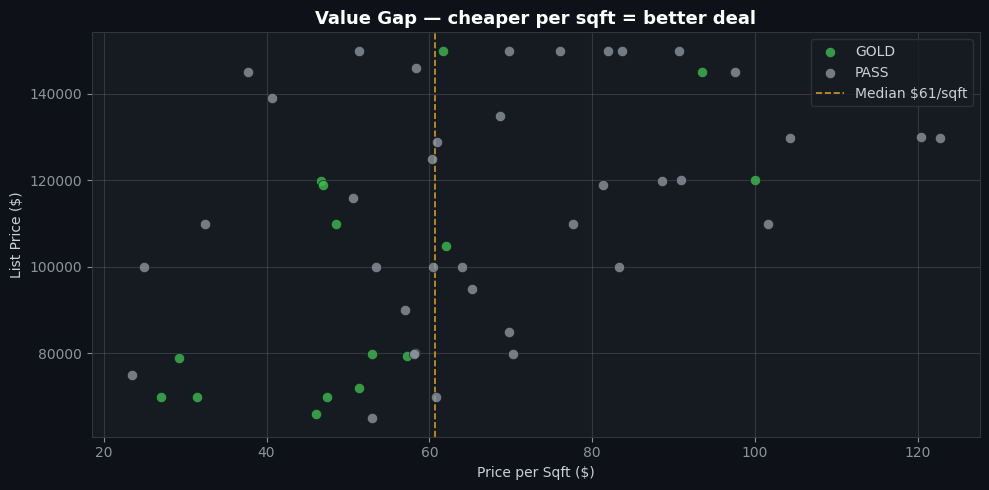

In [11]:
import matplotlib.pyplot as plt
import numpy as np

DARK = {"figure.facecolor": "#0e1117", "axes.facecolor": "#161b22",
        "axes.edgecolor": "#30363d", "axes.labelcolor": "#c9d1d9",
        "text.color": "#c9d1d9", "xtick.color": "#8b949e", "ytick.color": "#8b949e"}
CC = {"GOLD": "#3fb950", "AVOID": "#f85149", "PASS": "#8b949e"}

if not df_inv.empty and "price_per_sqft" in df_inv.columns:
    with plt.rc_context(DARK):
        fig, ax = plt.subplots(figsize=(10, 5))
        for c, color in CC.items():
            sub = df_inv[df_inv["cluster"] == c]
            if not sub.empty:
                ax.scatter(sub["price_per_sqft"], sub["price"], c=color, s=55, alpha=0.8,
                           edgecolors="#0e1117", linewidths=0.5, label=c, zorder=3)
        med = df_inv["price_per_sqft"].median()
        ax.axvline(med, color="#d29922", ls="--", lw=1.2, label=f"Median ${med:,.0f}/sqft")
        ax.set_xlabel("Price per Sqft ($)")
        ax.set_ylabel("List Price ($)")
        ax.set_title("Value Gap — cheaper per sqft = better deal", fontsize=13, fontweight="bold", color="white")
        ax.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="#c9d1d9")
        ax.grid(True, alpha=0.2)
        ax.spines[:].set_color("#30363d")
        plt.tight_layout()
        plt.show()

---

## Chart 2 — Who's been ignored?

Green dots in the **bottom-right** = cheap per sqft AND sitting a long time. The market rejected them but the bones are good.

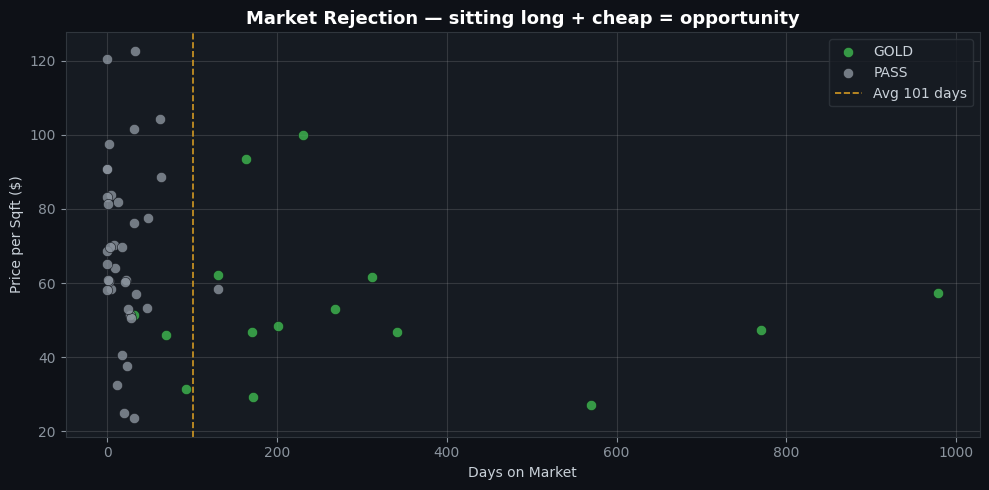

In [12]:
if not df_inv.empty and "days_on_market" in df_inv.columns and "price_per_sqft" in df_inv.columns:
    with plt.rc_context(DARK):
        fig, ax = plt.subplots(figsize=(10, 5))
        for c, color in CC.items():
            sub = df_inv[df_inv["cluster"] == c]
            if not sub.empty:
                ax.scatter(sub["days_on_market"], sub["price_per_sqft"], c=color, s=55, alpha=0.8,
                           edgecolors="#0e1117", linewidths=0.5, label=c, zorder=3)
        avg_dom = df_inv["days_on_market"].mean()
        ax.axvline(avg_dom, color="#d29922", ls="--", lw=1.2, label=f"Avg {avg_dom:.0f} days")
        ax.set_xlabel("Days on Market")
        ax.set_ylabel("Price per Sqft ($)")
        ax.set_title("Market Rejection — sitting long + cheap = opportunity", fontsize=13, fontweight="bold", color="white")
        ax.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="#c9d1d9")
        ax.grid(True, alpha=0.2)
        ax.spines[:].set_color("#30363d")
        plt.tight_layout()
        plt.show()

---

## Chart 3 — Score breakdown per property

Each bar shows exactly **which factors** made a property score high.

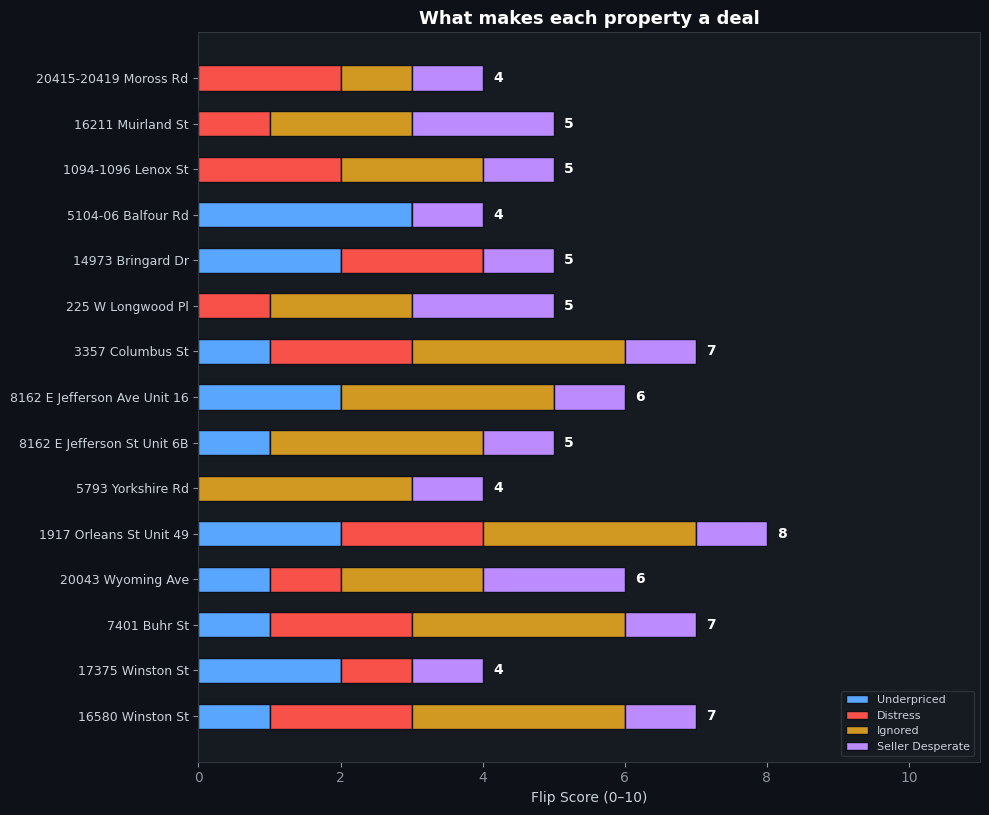

In [13]:
target = gold if not gold.empty else df_inv.nlargest(8, "flip_score")

if not target.empty:
    axes_cols = ["ax_value_gap", "ax_distress", "ax_market_reject", "ax_seller_weak"]
    axes_labels = ["Underpriced", "Distress", "Ignored", "Seller Desperate"]
    colors = ["#58a6ff", "#f85149", "#d29922", "#bc8cff"]
    addrs = target["address"].fillna("?").str[:28].tolist()
    n = len(addrs)

    with plt.rc_context(DARK):
        fig, ax = plt.subplots(figsize=(10, max(3, n * 0.55)))
        y = np.arange(n)
        left = np.zeros(n)
        for col, label, color in zip(axes_cols, axes_labels, colors):
            vals = target[col].fillna(0).values
            ax.barh(y, vals, left=left, color=color, edgecolor="#0e1117", label=label, height=0.55)
            left += vals
        for i, total in enumerate(target["flip_score"].values):
            ax.text(left[i] + 0.15, i, str(int(total)), va="center", color="white", fontweight="bold")
        ax.set_yticks(y)
        ax.set_yticklabels(addrs, fontsize=9, color="#c9d1d9")
        ax.invert_yaxis()
        ax.set_xlabel("Flip Score (0–10)")
        ax.set_title("What makes each property a deal", fontsize=13, fontweight="bold", color="white")
        ax.legend(loc="lower right", fontsize=8, facecolor="#161b22", edgecolor="#30363d", labelcolor="#c9d1d9")
        ax.set_xlim(0, 11)
        ax.spines[:].set_color("#30363d")
        plt.tight_layout()
        plt.show()

---

## The Picks

In [14]:
from IPython.display import display
display(picks_table(target))

,address,city,zip,price,beds,baths,sqft,price_per_sqft,days_on_market,flip_score,cluster
0,1917 Orleans St Unit 49,Detroit,48207,$70K,3.0,2.0,1478.0,$47,770,8,GOLD
1,3357 Columbus St,Detroit,48206,$70K,6.0,2.0,2588.0,$27,570,7,GOLD
2,7401 Buhr St,Detroit,48212,$80K,3.0,2.5,1390.0,$57,979,7,GOLD
3,16580 Winston St,Detroit,48219,$80K,3.0,1.5,1510.0,$53,268,7,GOLD
4,8162 E Jefferson Ave Unit 16A,Detroit,48214,$119K,3.0,2.5,2540.0,$47,341,6,GOLD
5,20043 Wyoming Ave,Detroit,48221,$110K,4.0,3.0,2267.0,$48,201,6,GOLD
6,16211 Muirland St,Detroit,48221,$145K,3.0,NaN,1550.0,$94,164,5,GOLD
7,1094-1096 Lenox St,Detroit,48215,$120K,6.0,2.0,2568.0,$47,171,5,GOLD
8,14973 Bringard Dr,Detroit,48205,$66K,3.0,1.5,1431.0,$46,69,5,GOLD
9,225 W Longwood Pl,Highland Park,48203,$79K,6.0,3.0,2704.0,$29,172,5,GOLD


---

## Bottom line

You don't find deals by searching for "cheap houses."

You find deals when **the market has already rejected the property — but the fundamentals are still strong.**

That's what GOLD means.